In [ ]:
import pandas as pd

df = pd.read_csv('furniture_10k_FINAL.csv', sep=';')

In [ ]:
# Membuat pivot table total sales per category dan status
pivot_sales = pd.pivot_table(
    df,
    values='total_sales',
    index='category',
    columns='status',
    aggfunc='sum'
)

# Tampilkan hasil
print(pivot_sales)

status       cancelled    completed      refund
category                                       
Dapur        593050000   9380070000   565670000
Kamar Tidur  965985000  17499895000  1000290000
Penyimpanan   90500000   1632355000    89150000
Ruang Kerja  108035000   1808565000    97615000
Ruang Makan  283802500   4783106000   286085000
Ruang Tamu   736080000  12376515000   733020000


In [ ]:
# Membuat kolom kota
df['kota'] = df['shipping_address'].str.split(', ').str[1]

# Filter status cancelled
cancelled_kota = (
    df[df['status'] == 'cancelled']
    .groupby('kota')
    .size()
    .sort_values(ascending=False)
)

# Tampilkan kota dengan cancelled terbanyak
print(cancelled_kota.head(1))

kota
Bekasi    67
dtype: int64


In [ ]:
import matplotlib.pyplot as plt

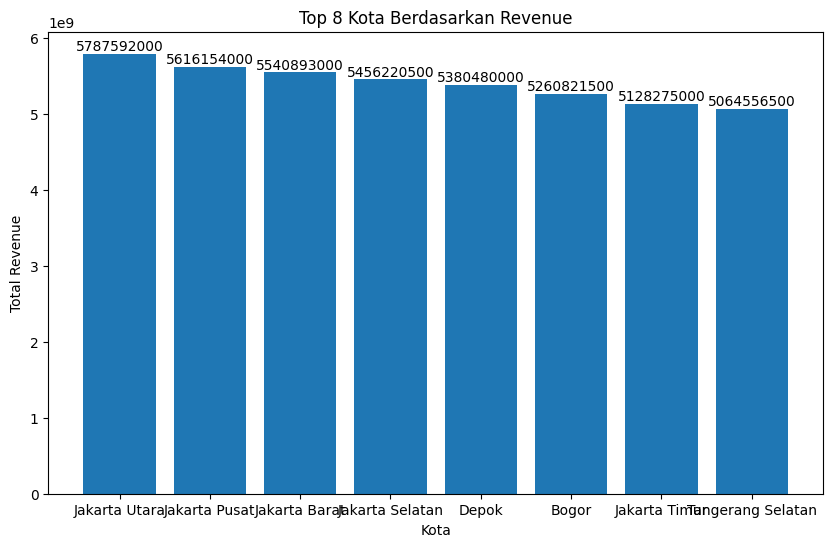

In [ ]:
# Membuat kolom kota dari shipping_address
df['kota'] = df['shipping_address'].str.split(', ').str[1]

# Hitung total revenue per kota
top_kota = (
    df.groupby('kota')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(8)
)

# Membuat bar chart
plt.figure(figsize=(10,6))
bars = plt.bar(top_kota.index, top_kota.values)

# Judul dan label
plt.title('Top 8 Kota Berdasarkan Revenue')
plt.xlabel('Kota')
plt.ylabel('Total Revenue')

# Tambahkan label angka di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

# Tampilkan chart
plt.show()

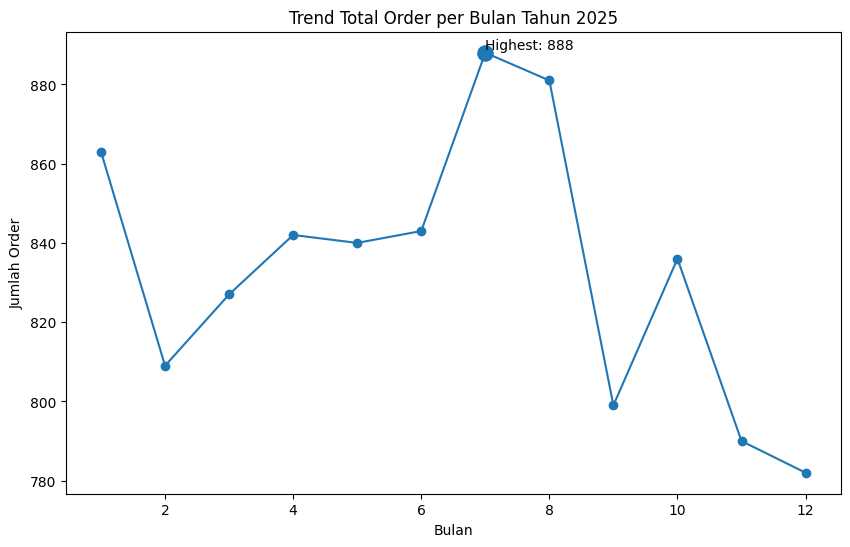

In [ ]:
# Ubah sales_date ke datetime
df['sales_date'] = pd.to_datetime(df['sales_date'])

# Ambil bulan dari sales_date
df['month'] = df['sales_date'].dt.month

# Hitung total order per bulan
monthly_orders = (
    df.groupby('month')['order_id']
    .count()
)

# Cari bulan dengan order tertinggi
max_month = monthly_orders.idxmax()
max_value = monthly_orders.max()

# Membuat line chart
plt.figure(figsize=(10,6))

plt.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker='o'
)

# Highlight titik tertinggi
plt.scatter(
    max_month,
    max_value,
    s=120
)

# Tambahkan label titik tertinggi
plt.text(
    max_month,
    max_value,
    f'Highest: {max_value}',
    ha='left',
    va='bottom'
)

# Judul dan label
plt.title('Trend Total Order per Bulan Tahun 2025')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Order')

# Tampilkan chart
plt.show()